$$\mathscr{E}_s^2 = \frac{2q V_{th} N_a}{\epsilon_{si}} \left[ \left( exp(-\frac{\psi_{sd}}{V_{th}}) + \frac{\psi_{sd}}{V_{th}} -1 \right) right]$$

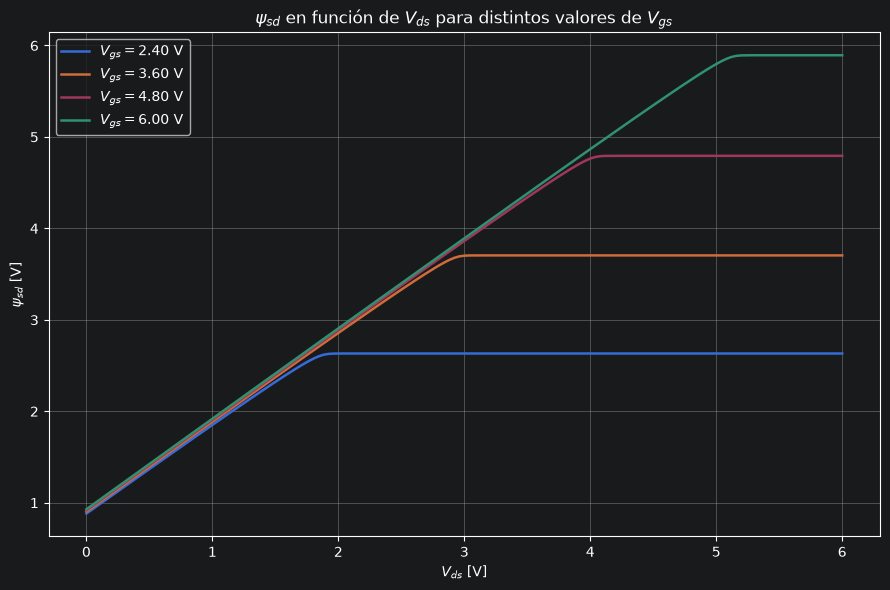

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import brentq


# ============================================================
# PARÁMETROS DEL DISPOSITIVO
# Usar unidades consistentes, en este ejemplo se usa SI.
# ============================================================

q = 1.602176634e-19           # C
Vth = 0.025875                 # V

Na = 7.0e15                   # 1/cm^3
ni = 1.0e10                   # 1/cm^3

epsilon_0 = 88.541878128e-15  # F/cm
epsilon_si = 11.7 * epsilon_0 # F/m

Cox = 115.05e-9                 # F/cm^2

VFB = -0.9082                    # V

VDD = 6

PHI_B = -0.3482

# ============================================================
# VALORES A BARRER
# ============================================================

Vds_values = np.linspace(0.0, VDD, 151)

Vgs_values = [
    0.4*VDD,
    0.6*VDD,
    0.8*VDD,
    VDD
]


# Intervalo de búsqueda de psi_sd
psi_min = -0.5
psi_max = 10

# Resolución del barrido usado para encontrar cambios de signo
number_of_scan_points = 5000

# Valor esperado para psi_sd al comienzo de cada curva
psi_initial_hint = 0.5


# ============================================================
# CAMPO ELÉCTRICO AL CUADRADO
# ============================================================

def electric_field_squared(psi_sd, Vds):
    """
    Calcula E_s^2 según la primera ecuación.
    """

    normalized_psi = psi_sd / Vth
    normalized_vds = -Vds / Vth

    # Protección contra overflow en las exponenciales
    normalized_psi = np.clip(
        normalized_psi,
        -700.0,
        700.0
    )

    normalized_vds = np.clip(
        normalized_vds,
        -700.0,
        700.0
    )

    majority_carrier_term = (
        np.exp(-normalized_psi)
        + normalized_psi
        - 1.0
    )

    minority_carrier_term = (
        np.exp(normalized_vds)
        * np.expm1(normalized_psi)
        - normalized_psi
    )

    bracket = (
        majority_carrier_term
        + (ni / Na) ** 2 * minority_carrier_term
    )

    return (
        2.0 * q * Vth * Na / epsilon_si
    ) * bracket


# ============================================================
# CARGA SUPERFICIAL
# ============================================================

def surface_charge(psi_sd, Vgs):
    """
    Q'_s = -Cox(Vgs - VFB - psi_sd)
    """

    return -Cox * (Vgs - VFB - psi_sd)


# ============================================================
# ECUACIÓN RESIDUAL
# ============================================================

def residual(psi_sd, Vds, Vgs):
    """
    Se resuelve:

        Q'_s^2 - epsilon_si^2 E_s^2 = 0

    Se supone que la segunda ecuación correcta es:

        E_s^2 = (Q'_s / epsilon_si)^2
    """

    Qs = surface_charge(psi_sd, Vgs)
    E2 = electric_field_squared(psi_sd, Vds)

    return Qs**2 - epsilon_si**2 * E2


# ============================================================
# ENCONTRAR TODAS LAS RAÍCES
# ============================================================

def find_all_roots(Vds, Vgs):
    """
    Encuentra todas las raíces dentro de:
        psi_min <= psi_sd <= psi_max
    """

    psi_grid = np.linspace(
        psi_min,
        psi_max,
        number_of_scan_points
    )

    residual_values = np.array([
        residual(psi, Vds, Vgs)
        for psi in psi_grid
    ])

    roots = []

    for index in range(len(psi_grid) - 1):
        psi_left = psi_grid[index]
        psi_right = psi_grid[index + 1]

        residual_left = residual_values[index]
        residual_right = residual_values[index + 1]

        if not (
            np.isfinite(residual_left)
            and np.isfinite(residual_right)
        ):
            continue

        if residual_left == 0.0:
            roots.append(psi_left)

        elif residual_left * residual_right < 0.0:
            root = brentq(
                lambda psi: residual(
                    psi,
                    Vds,
                    Vgs
                ),
                psi_left,
                psi_right,
                xtol=1e-12,
                rtol=1e-12,
                maxiter=200
            )

            roots.append(root)

    # Eliminar raíces repetidas
    roots = sorted(roots)
    unique_roots = []

    for root in roots:
        if (
            len(unique_roots) == 0
            or abs(root - unique_roots[-1]) > 1e-7
        ):
            unique_roots.append(root)

    return np.array(unique_roots)


# ============================================================
# CALCULAR UNA CURVA COMPLETA PARA UN Vgs
# ============================================================

def calculate_psi_curve(Vds_array, Vgs):
    """
    Sigue una misma rama de soluciones.

    Para el primer Vds elige la raíz más cercana a
    psi_initial_hint.

    Para los siguientes valores de Vds elige la raíz más
    cercana a la solución anterior.
    """

    psi_results = np.full(
        len(Vds_array),
        np.nan
    )

    previous_psi = None

    for index, Vds in enumerate(Vds_array):
        roots = find_all_roots(Vds, Vgs)

        # Opcional:
        # conservar solamente soluciones psi_sd >= 0
        roots = roots[roots >= 0.0]

        if len(roots) == 0:
            print(
                f"No se encontró solución para "
                f"Vgs = {Vgs:.3f} V, "
                f"Vds = {Vds:.3f} V"
            )
            continue

        if previous_psi is None:
            selected_root_index = np.argmin(
                np.abs(roots - psi_initial_hint)
            )
        else:
            selected_root_index = np.argmin(
                np.abs(roots - previous_psi)
            )

        selected_root = roots[selected_root_index]

        psi_results[index] = selected_root
        previous_psi = selected_root

    return psi_results


# ============================================================
# CALCULAR Y GRAFICAR TODAS LAS CURVAS
# ============================================================

plt.figure(figsize=(9, 6))

for Vgs in Vgs_values:
    psi_sd_values = calculate_psi_curve(
        Vds_values,
        Vgs
    )

    plt.plot(
        Vds_values,
        psi_sd_values,
        linewidth=1.8,
        label=rf"$V_{{gs}}={Vgs:.2f}\ \mathrm{{V}}$"
    )




plt.xlabel(r"$V_{ds}$ [V]")
plt.ylabel(r"$\psi_{sd}$ [V]")

plt.title(
    r"$\psi_{sd}$ en función de $V_{ds}$ "
    r"para distintos valores de $V_{gs}$"
)

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()